In [2]:

import warnings
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, matthews_corrcoef, classification_report, confusion_matrix
)

from imblearn.over_sampling import SMOTE
import xgboost as xgb
import shap

warnings.filterwarnings("ignore")

# ------------------------------------------------------------------------------
# REPRODUCIBILITY
# ------------------------------------------------------------------------------
RANDOM_SEED = 32
np.random.seed(RANDOM_SEED)
random.seed(RANDOM_SEED)

DATA_PATH = r"D:\DataCoSupplyChainDataset.csv" 
TARGET = "Late_delivery_risk"                

# Columns removed for excessive missingness / irrelevance 
COLUMNS_TO_DROP = [
    "Order Zipcode", "Product Description",
    "Customer Fname", "Customer Lname", "Customer Email"
]

# NEW: identifier-type columns — no genuine predictive value, risk of
# memorization/overfitting rather than learning real patterns
IDENTIFIER_COLUMNS = [
    "Order Id", "Order Item Id", "Customer Id", "Product Card Id",
    "Product Image", "Customer Password", "Customer Street","Order Customer Id",     
    "Latitude", "Longitude",
]

# Post-delivery variables identified as data leakage (Section 3.4)
# "shipping date (DateOrders)" added — same category of problem as
# Days for shipping (Real): not knowable at order-placement time
LEAKAGE_COLUMNS = [
    "Days for shipping (real)", "Delivery Status",
    "shipping date (DateOrders)"
]

# NOTE: "Order Status" is kept in for now, but its exact definition
# (status at order time vs. final/current status) should be verified
# against the dataset documentation before treating it as safe.


# ==============================================================================
# SECTION 3.1 - 3.2 : DATA LOADING & PREPROCESSING
# ==============================================================================
def load_and_preprocess(path: str):
    df = pd.read_csv(path, encoding="latin-1")

    drop_now = [c for c in (COLUMNS_TO_DROP + IDENTIFIER_COLUMNS) if c in df.columns]
    df = df.drop(columns=drop_now)
    print(f"Dropped columns (missing/irrelevant/identifier): {drop_now}")

    before = len(df)
    df = df.dropna()
    print(f"Dropped {before - len(df)} rows with missing values "
          f"({len(df)} rows remain)")

    cat_cols = df.select_dtypes(include=["object"]).columns.tolist()
    for col in cat_cols:
        df[col] = LabelEncoder().fit_transform(df[col].astype(str))
    print(f"Label-encoded {len(cat_cols)} categorical columns")

    return df


df = load_and_preprocess(DATA_PATH)

X_full = df.drop(columns=[TARGET])
y_full = df[TARGET]

# ==============================================================================
# SECTION 3.4 : DATA LEAKAGE DETECTION & CORRECTION
# ==============================================================================
leak_present = [c for c in LEAKAGE_COLUMNS if c in X_full.columns]
print(f"\nRemoving post-delivery (leakage) columns: {leak_present}")
X_full = X_full.drop(columns=leak_present)

feature_names = X_full.columns.tolist()
n_features = len(feature_names)
print(f"Candidate features entering GA selection: {n_features}")
print(feature_names)


# ==============================================================================
# SECTION 3.3 : GA-BASED WRAPPER FEATURE SELECTION
# Population=30, Generations=10, Crossover=0.5, Mutation=0.2
# Fitness = RandomForest, 3-fold stratified CV, F1-score
# Run on a stratified 20% sample for computational efficiency
# Fitness evaluation across the population is parallelized (joblib)
# ==============================================================================
POP_SIZE = 30
N_GENERATIONS = 10
CROSSOVER_PROB = 0.5
MUTATION_PROB = 0.2
N_JOBS = -1   # uses all available threads for parallel fitness evaluation

X_ga_sample, _, y_ga_sample, _ = train_test_split(
    X_full, y_full, train_size=0.20, stratify=y_full, random_state=RANDOM_SEED
)


def fitness(chromosome, X, y):
    selected = [f for f, bit in zip(feature_names, chromosome) if bit == 1]
    if not selected:
        return 0.0
    # n_jobs=1 here — parallelism happens one level up, across the population,
    # to avoid nested-thread oversubscription
    clf = RandomForestClassifier(n_estimators=100, random_state=RANDOM_SEED, n_jobs=1)
    skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)
    scores = []
    for train_idx, val_idx in skf.split(X[selected], y):
        clf.fit(X[selected].iloc[train_idx], y.iloc[train_idx])
        preds = clf.predict(X[selected].iloc[val_idx])
        scores.append(f1_score(y.iloc[val_idx], preds))
    return float(np.mean(scores))


def evaluate_population(population, X, y):
    return Parallel(n_jobs=N_JOBS)(
        delayed(fitness)(chrom, X, y) for chrom in population
    )


def init_population(pop_size, n_feat):
    return [np.random.randint(0, 2, n_feat).tolist() for _ in range(pop_size)]


def tournament_select(pop, fitnesses, k=3):
    idx = np.random.choice(len(pop), k, replace=False)
    best = max(idx, key=lambda i: fitnesses[i])
    return pop[best]


def crossover(p1, p2):
    if random.random() < CROSSOVER_PROB:
        point = random.randint(1, len(p1) - 1)
        return p1[:point] + p2[point:], p2[:point] + p1[point:]
    return p1[:], p2[:]


def mutate(chromosome):
    return [1 - bit if random.random() < MUTATION_PROB else bit for bit in chromosome]


def run_ga(X, y):
    population = init_population(POP_SIZE, n_features)
    best_chromosome, best_fit = None, -1.0

    for gen in range(N_GENERATIONS):
        fitnesses = evaluate_population(population, X, y)
        gen_best_idx = int(np.argmax(fitnesses))
        if fitnesses[gen_best_idx] > best_fit:
            best_fit = fitnesses[gen_best_idx]
            best_chromosome = population[gen_best_idx][:]
        print(f"  Generation {gen + 1}/{N_GENERATIONS} — best F1: {max(fitnesses):.4f}")

        new_population = [population[gen_best_idx]]  # elitism
        while len(new_population) < POP_SIZE:
            parent1 = tournament_select(population, fitnesses)
            parent2 = tournament_select(population, fitnesses)
            child1, child2 = crossover(parent1, parent2)
            new_population.append(mutate(child1))
            if len(new_population) < POP_SIZE:
                new_population.append(mutate(child2))
        population = new_population

    return best_chromosome, best_fit


print("\nRunning GA-based feature selection...")
best_chromosome, best_fit = run_ga(X_ga_sample, y_ga_sample)
selected_features = [f for f, bit in zip(feature_names, best_chromosome) if bit == 1]
print(f"\nGA selected {len(selected_features)}/{n_features} features "
      f"(best CV F1 = {best_fit:.4f})")
print("Selected features:", selected_features)

X_selected = X_full[selected_features]


# ==============================================================================
# TRAIN / TEST SPLIT (80:20, stratified)
# ==============================================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_full, test_size=0.20, stratify=y_full, random_state=RANDOM_SEED
)


# ==============================================================================
# CLASS IMBALANCE HANDLING — SMOTE (training set only)
# ==============================================================================
print(f"\nBefore SMOTE — class distribution: {y_train.value_counts().to_dict()}")
smote = SMOTE(random_state=RANDOM_SEED)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)
print(f"After SMOTE  — class distribution: {y_train_res.value_counts().to_dict()}")


# ==============================================================================
# HYPERPARAMETER TUNING — RandomizedSearchCV
# n_jobs fixed to avoid oversubscription: outer search uses all threads,
# inner XGBoost estimator uses 1 thread per fit
# ==============================================================================
param_dist = {
    "n_estimators": [100, 200, 300, 400, 500],
    "max_depth": [3, 4, 5, 6, 7, 8, 10],
    "learning_rate": [0.01, 0.03, 0.05, 0.1, 0.15, 0.2],
    "subsample": [0.6, 0.7, 0.8, 0.9, 1.0],
    "colsample_bytree": [0.6, 0.7, 0.8, 0.9, 1.0],
    "gamma": [0, 0.1, 0.2, 0.3, 0.5],
    "min_child_weight": [1, 3, 5, 7],
}

xgb_base = xgb.XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    random_state=RANDOM_SEED,
    n_jobs=1,          # avoid nested oversubscription with outer n_jobs=-1
)

cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=50,
    scoring="f1",
    cv=cv_strategy,
    random_state=RANDOM_SEED,
    n_jobs=-1,          # outer loop uses all threads
    verbose=1,
)

print("\nRunning RandomizedSearchCV for hyperparameter tuning "
      "(50 candidates x 5-fold CV = 250 fits)...")
search.fit(X_train_res, y_train_res)

print(f"\nBest hyperparameters: {search.best_params_}")
print(f"Best CV F1-score (train, resampled): {search.best_score_:.4f}")

best_model = search.best_estimator_


# ==============================================================================
# SECTION 3.5 (ENHANCED) : FINAL MODEL EVALUATION ON HELD-OUT TEST SET
# ==============================================================================
y_pred = best_model.predict(X_test)
y_proba = best_model.predict_proba(X_test)[:, 1]

metrics = {
    "Accuracy": accuracy_score(y_test, y_pred),
    "Precision": precision_score(y_test, y_pred),
    "Recall": recall_score(y_test, y_pred),
    "F1-score": f1_score(y_test, y_pred),
    "AUC-ROC": roc_auc_score(y_test, y_proba),
    "MCC": matthews_corrcoef(y_test, y_pred),
}

print("\n=== Final Model Performance (held-out test set) ===")
for k, v in metrics.items():
    print(f"{k:12s}: {v:.4f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["On-Time (0)", "Late (1)"]))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))


# ==============================================================================
# SECTION 3.6 : SHAP EXPLAINABILITY
# ==============================================================================
explainer = shap.TreeExplainer(best_model)
shap_values = explainer.shap_values(X_test)

shap.summary_plot(shap_values, X_test, plot_type="bar", show=False)
plt.tight_layout()
plt.savefig("shap_feature_importance_bar.png", dpi=150)
plt.close()

shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig("shap_summary_dot.png", dpi=150)
plt.close()

print("\nSHAP plots saved: shap_feature_importance_bar.png, shap_summary_dot.png")

# Quick sanity check — flag if any identifier-like feature slipped through
# and still shows high importance (shouldn't happen now, but worth checking)
mean_abs_shap = np.abs(shap_values).mean(axis=0)
shap_importance = pd.Series(mean_abs_shap, index=selected_features).sort_values(ascending=False)
print("\nTop 10 features by mean |SHAP value|:")
print(shap_importance.head(10))


# ==============================================================================
# SAVE RESULTS
# ==============================================================================
pd.DataFrame([metrics]).to_csv("model_performance_metrics.csv", index=False)
pd.DataFrame({"selected_feature": selected_features}).to_csv(
    "ga_selected_features.csv", index=False
)
pd.DataFrame([search.best_params_]).to_csv("best_hyperparameters.csv", index=False)
shap_importance.to_csv("shap_feature_importance.csv", header=["mean_abs_shap"])

print("\nPipeline complete.")
print("  - model_performance_metrics.csv")
print("  - ga_selected_features.csv")
print("  - best_hyperparameters.csv")
print("  - shap_feature_importance.csv")
print("  - shap_feature_importance_bar.png / shap_summary_dot.png")

import pickle
with open('best_model.pkl', 'wb') as f:
    pickle.dump(best_model, f)
X_test.to_pickle('X_test.pkl')
y_test.to_pickle('y_test.pkl')
pd.Series(y_pred).to_pickle('y_pred.pkl')

Dropped columns (missing/irrelevant/identifier): ['Order Zipcode', 'Product Description', 'Customer Fname', 'Customer Lname', 'Customer Email', 'Order Id', 'Order Item Id', 'Customer Id', 'Product Card Id', 'Product Image', 'Customer Password', 'Customer Street', 'Order Customer Id', 'Latitude', 'Longitude']
Dropped 3 rows with missing values (180516 rows remain)
Label-encoded 18 categorical columns

Removing post-delivery (leakage) columns: ['Days for shipping (real)', 'Delivery Status', 'shipping date (DateOrders)']
Candidate features entering GA selection: 34
['Type', 'Days for shipment (scheduled)', 'Benefit per order', 'Sales per customer', 'Category Id', 'Category Name', 'Customer City', 'Customer Country', 'Customer Segment', 'Customer State', 'Customer Zipcode', 'Department Id', 'Department Name', 'Market', 'Order City', 'Order Country', 'order date (DateOrders)', 'Order Item Cardprod Id', 'Order Item Discount', 'Order Item Discount Rate', 'Order Item Product Price', 'Order Ite

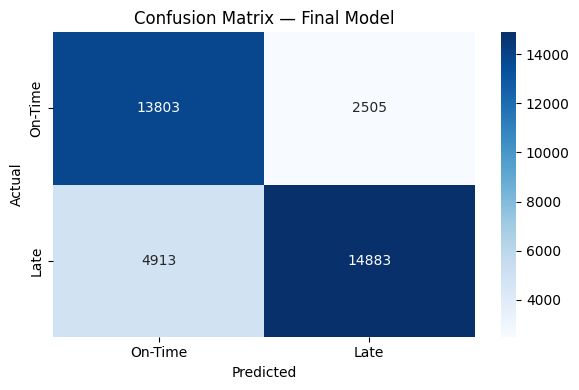

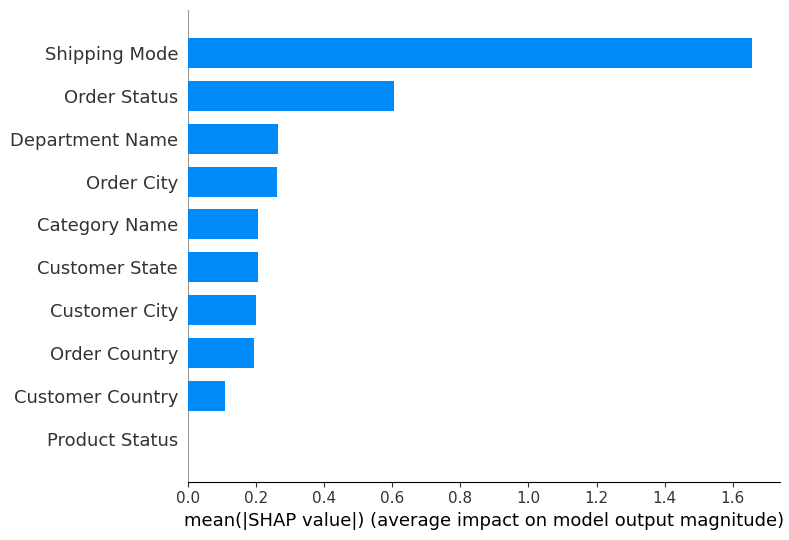

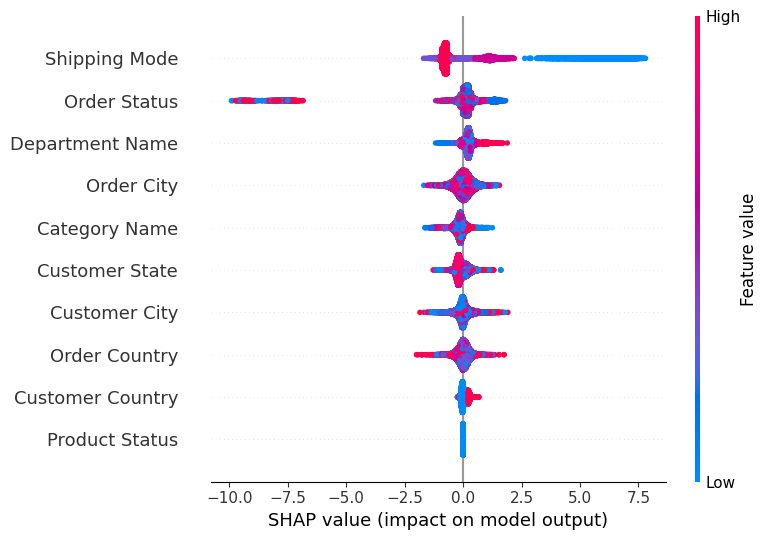

All figures saved as PNG (300 DPI — publication ready)
  - confusion_matrix_final.png
  - shap_bar_final.png
  - shap_dot_final.png


In [4]:
# ============================================================
# Generate Final Figures — Confusion Matrix + SHAP
# (Run this AFTER the main pipeline, in the same notebook /
#  same kernel session, so that best_model, X_test, y_test,
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.metrics import confusion_matrix

# ── Figure 1: Confusion Matrix ────────────────────────────
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['On-Time', 'Late'],
            yticklabels=['On-Time', 'Late'])
plt.title('Confusion Matrix — Final Model')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('confusion_matrix_final.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 2: SHAP Bar Plot ────────────────────────────────
explainer = shap.TreeExplainer(best_model)          # <-- fixed: was 'model'
shap_values = explainer.shap_values(X_test)

plt.figure()
shap.summary_plot(shap_values, X_test, plot_type='bar', show=False)
plt.tight_layout()
plt.savefig('shap_bar_final.png', dpi=300, bbox_inches='tight')
plt.show()

# ── Figure 3: SHAP Dot Plot ────────────────────────────────
plt.figure()
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_dot_final.png', dpi=300, bbox_inches='tight')
plt.show()

print("All figures saved as PNG (300 DPI)")
print("  - confusion_matrix_final.png")
print("  - shap_bar_final.png")
print("  - shap_dot_final.png")

In [5]:
# ============================================================
# Decode Label-Encoded Columns Back to Original Category Names
# ------------------------------------------------------------
# Lightweight, standalone — reloads raw data and re-applies the
# SAME preprocessing steps as the main pipeline (same column drops,
# same dropna) so that the encoding matches exactly what the model
# was trained on.
#
# Use this to interpret the SHAP dot plot: e.g. "Shipping Mode = 3"
# corresponds to which actual shipping mode category.
# ============================================================

import pandas as pd
from sklearn.preprocessing import LabelEncoder

DATA_PATH = r"D:\DataCoSupplyChainDataset.csv"  

COLUMNS_TO_DROP = [
    "Order Zipcode", "Product Description",
    "Customer Fname", "Customer Lname", "Customer Email"
]

IDENTIFIER_COLUMNS = [
    "Order Id", "Order Item Id", "Customer Id", "Product Card Id",
    "Product Image", "Customer Password", "Customer Street",
    "Order Customer Id", "Latitude", "Longitude",
]

# Features you most need decoded for the discussion section —
# add more column names here if you want their mappings too
FEATURES_OF_INTEREST = [
    "Shipping Mode", "Order Status", "Department Name",
    "Order City", "Category Name", "Customer State",
    "Customer City", "Order Country", "Customer Country",
    "Product Status"
]

# ------------------------------------------------------------
# Load and preprocess EXACTLY like the main pipeline
# ------------------------------------------------------------
df = pd.read_csv(DATA_PATH, encoding="latin-1")
drop_now = [c for c in (COLUMNS_TO_DROP + IDENTIFIER_COLUMNS) if c in df.columns]
df = df.drop(columns=drop_now)
df = df.dropna()

cat_cols = df.select_dtypes(include=["object"]).columns.tolist()

# ------------------------------------------------------------
# Fit LabelEncoder per categorical column and record the mapping
# ------------------------------------------------------------
all_mappings = {}

for col in cat_cols:
    le = LabelEncoder()
    le.fit(df[col].astype(str))
    mapping = {int(code): label for code, label in enumerate(le.classes_)}
    all_mappings[col] = mapping

# ------------------------------------------------------------
# Print mappings for the SHAP top-feature columns (for discussion section)
# ------------------------------------------------------------
print("=== Encoded Value -> Original Category (SHAP top features) ===\n")
for col in FEATURES_OF_INTEREST:
    if col in all_mappings:
        print(f"--- {col} ---")
        for code, label in all_mappings[col].items():
            print(f"  {code} : {label}")
        print()
    else:
        print(f"--- {col} : not found in categorical columns (check spelling) ---\n")

# ------------------------------------------------------------
# Save ALL column mappings to a single CSV for reference
# ------------------------------------------------------------
rows = []
for col, mapping in all_mappings.items():
    for code, label in mapping.items():
        rows.append({"column": col, "encoded_value": code, "original_category": label})

mapping_df = pd.DataFrame(rows)
mapping_df.to_csv("label_encoding_mappings.csv", index=False)
print("Full mapping table saved to: label_encoding_mappings.csv")

=== Encoded Value -> Original Category (SHAP top features) ===

--- Shipping Mode ---
  0 : First Class
  1 : Same Day
  2 : Second Class
  3 : Standard Class

--- Order Status ---
  0 : CANCELED
  1 : CLOSED
  2 : COMPLETE
  3 : ON_HOLD
  4 : PAYMENT_REVIEW
  5 : PENDING
  6 : PENDING_PAYMENT
  7 : PROCESSING
  8 : SUSPECTED_FRAUD

--- Department Name ---
  0 : Apparel
  1 : Book Shop
  2 : Discs Shop
  3 : Fan Shop
  4 : Fitness
  5 : Footwear
  6 : Golf
  7 : Health and Beauty 
  8 : Outdoors
  9 : Pet Shop
  10 : Technology

--- Order City ---
  0 : Aachen
  1 : Aalen
  2 : Aalst
  3 : Aba
  4 : Abadan
  5 : Abakaliki
  6 : Abbeville
  7 : Abbotsford
  8 : Abeokuta
  9 : Aberdeen
  10 : Abha
  11 : Abidjan
  12 : Abilene
  13 : Abreu e Lima
  14 : Abu Kabir
  15 : Acarigua
  16 : Acayucan
  17 : Accra
  18 : Acerra
  19 : Acireale
  20 : Acuña
  21 : Acámbaro
  22 : Ad Diwaniyah
  23 : Ad Diwem
  24 : Adana
  25 : Adelaide
  26 : Adiyaman
  27 : Aew?l-li
  28 : Afragola
  29 : Afyo

In [6]:
# ============================================================
# Exact SHAP Impact Per Category (Shipping Mode, Order Status, etc.)
# ------------------------------------------------------------
# Instead of eyeballing colors on the SHAP dot plot, this computes
# the ACTUAL mean SHAP value for each encoded category — giving an
# unambiguous, quotable number for the discussion section.
#
# Run this in the SAME kernel session as the main pipeline, AFTER
# shap_values and X_test already exist (or after loading them back
# from the .pkl files if you saved those).
# ============================================================

import numpy as np
import pandas as pd

# Mapping from earlier decode_label_encodings.py output
# (edit/extend this dict if you decode more columns later)
CATEGORY_MAPS = {
    "Shipping Mode": {
        0: "First Class", 1: "Same Day", 2: "Second Class", 3: "Standard Class"
    },
    "Order Status": {
        0: "CANCELED", 1: "CLOSED", 2: "COMPLETE", 3: "ON_HOLD",
        4: "PAYMENT_REVIEW", 5: "PENDING", 6: "PENDING_PAYMENT",
        7: "PROCESSING", 8: "SUSPECTED_FRAUD"
        # add more if your data has additional status codes
    },
}

# Which features to analyze (must match column names in X_test / selected_features)
FEATURES_TO_ANALYZE = ["Shipping Mode", "Order Status"]

# ------------------------------------------------------------
# shap_values shape: (n_samples, n_features), matching X_test columns
# ------------------------------------------------------------
shap_df = pd.DataFrame(shap_values, columns=X_test.columns, index=X_test.index)

for feature in FEATURES_TO_ANALYZE:
    if feature not in X_test.columns:
        print(f"'{feature}' not in selected features — skipping.\n")
        continue

    print(f"=== Mean SHAP value by category: {feature} ===")

    temp = pd.DataFrame({
        "encoded_value": X_test[feature].values,
        "shap_value": shap_df[feature].values
    })

    summary = (
        temp.groupby("encoded_value")["shap_value"]
        .agg(mean_shap="mean", count="count")
        .sort_values("mean_shap", ascending=False)
    )

    mapping = CATEGORY_MAPS.get(feature, {})
    summary["category"] = [mapping.get(int(v), f"code_{int(v)}") for v in summary.index]
    summary = summary[["category", "mean_shap", "count"]]

    print(summary.to_string())
    print(f"\n  --> Positive mean SHAP = pushes prediction toward LATE (risk-increasing)")
    print(f"  --> Negative mean SHAP = pushes prediction toward ON-TIME (risk-reducing)\n")

    summary.to_csv(f"shap_by_category_{feature.replace(' ', '_')}.csv")

print("Category-level SHAP summaries saved as CSV files.")

=== Mean SHAP value by category: Shipping Mode ===
                     category  mean_shap  count
encoded_value                                  
0                 First Class   6.165994   5535
2                Second Class   1.148980   7067
1                    Same Day  -0.405478   1958
3              Standard Class  -0.771323  21544

  --> Positive mean SHAP = pushes prediction toward LATE (risk-increasing)
  --> Negative mean SHAP = pushes prediction toward ON-TIME (risk-reducing)

=== Mean SHAP value by category: Order Status ===
                      category  mean_shap  count
encoded_value                                   
2                     COMPLETE   0.328037  11927
6              PENDING_PAYMENT   0.223765   7988
5                      PENDING   0.193593   4049
3                      ON_HOLD   0.183775   2010
7                   PROCESSING   0.065579   4415
1                       CLOSED   0.064378   3791
4               PAYMENT_REVIEW  -0.354318    362
8              SU

In [1]:
%pwd

'C:\\Users\\anik3'